In [1]:
import matplotlib.pyplot as plt
import numpy as np
import scipy as sp

In [2]:
procs = []
times = []

with open("timings_static.txt") as f:
    next(f)
    for line in f:
        p, t = line.split()
        procs.append(int(p))
        times.append(float(t))

procs = np.array(procs)
times = np.array(times)

t1 = times[0]
speedup = [t1/t for t in times]

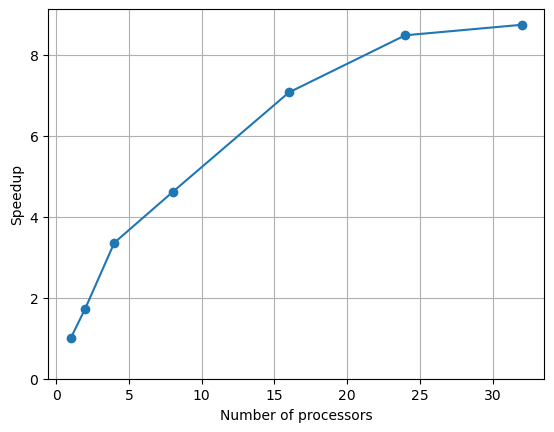

In [3]:
plt.plot(procs, speedup, marker='o')
plt.xlabel("Number of processors")
plt.ylabel("Speedup")
#plt.xlim(np.min(procs),np.max(procs))
plt.ylim(0)
#plt.savefig('5_static_speedup.png')
plt.grid(True)
plt.show()

Estimated parallel fraction according to Amdahl's law:  [0.91602828]


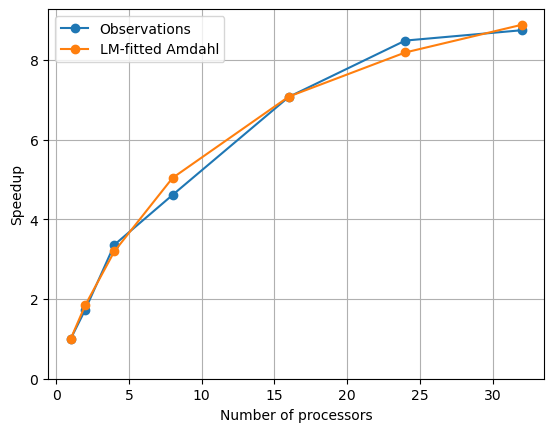

In [7]:
# Fit and plot speed up
# Code from course 02610 Optimisation and data fitting
n_proc = procs.flatten()
speedup_observation = np.array(speedup).flatten()
T1 = times[0]

def fun_f(F, n_proc, speedup_observation):
    p = n_proc
    return speedup_observation - T1 / ((1-F)*T1 + F/p *T1)

# Guess
F0 = np.array([0.9])

# Solve using trust-region-reflective algorithm
from scipy.optimize import least_squares

plt.figure()
plt.plot(n_proc, speedup_observation, label='Observations', marker="o")

# Solve using levenberg-marquardt algorithm
res = least_squares(fun_f, F0, args=(n_proc, speedup_observation), method='lm', ftol=1e-10, xtol=1e-10)
Fopt = res.x
print("Estimated parallel fraction according to Amdahl's law: ", Fopt)
plt.plot(n_proc, T1 / ((1-Fopt)*T1 + Fopt/n_proc *T1), marker="o", label='LM-fitted Amdahl')
plt.legend()
plt.xlabel("Number of processors")
plt.ylabel("Speedup")
#plt.xlim(np.min(n_proc),np.max(n_proc))
plt.ylim(0)
#plt.savefig('5_static_fitted_speedup.png')
plt.grid(True)

plt.show()


In [8]:
# Theoretical max speedup
S_max = 1/(1-Fopt)
our_S_max = np.max(speedup_observation)
our_S_max_index = np.argmax(speedup_observation)
our_S_max_cores = procs[our_S_max_index]

# Time to compute for all buildings
n_buildings = 4571
n_observations = 100
observations_per_chunk = n_observations/our_S_max_cores
all_buildings_per_chunk = n_buildings/our_S_max_cores
times_longer_for_all = all_buildings_per_chunk/observations_per_chunk

# Print results for project handin
print(f"Theoretical max speedup: {S_max}.")
print(f"Acheived of theoretical max speedup: {our_S_max/S_max} using {our_S_max_cores} cores.")
print(f"Theoretically, it would take {times_longer_for_all} times longer computing all buildings.")
print(f"With {n_observations} buildings it took {times[our_S_max_index]} seconds, meaning {times[our_S_max_index]/60/60} hours.")
print(f"With {n_buildings} buildings it will estimatetly take {times[our_S_max_index]*times_longer_for_all} seconds, meaning {times[our_S_max_index]*times_longer_for_all/60/60} hours.")

Theoretical max speedup: [11.90877076].
Acheived of theoretical max speedup: [0.73433787] using 32 cores.
Theoretically, it would take 45.71 times longer computing all buildings.
With 100 buildings it took 141.012 seconds, meaning 0.03917 hours.
With 4571 buildings it will estimatetly take 6445.65852 seconds, meaning 1.7904607000000001 hours.


In [6]:
n_buildings/n_observations

45.71